# 01211373 : Machine Learning and Programming for Industry

## Lecture 5 Supplement 1 : Feature Dimensionality Reduction

In this lecture, we discuss two fundamental techniques that will help you to summarize the information content of a dataset by transforming it onto a new feature subspace of lower dimensionality than the original one. The materials in this notebook follows chapter 5 of [1] and chapter 12 of [2] (PCA). 

* Principal component analysis for unsupervised data compression
* Linear discriminant analysis as a supervised dimensionality reduction technique for maximizing
class separability

### 7.1 Principal Component Analysis (PCA) 

**Note :** The PCA discussion below mainly follows [2] and [this lecture video](https://youtu.be/I_c6w1SJSJs?si=J9jcwv00ifYZrCPA), though we have found that [this lecture video](https://youtu.be/xBf_LZ5ZgY4?si=rCYdv03EKkp41fby) from the University of Tübingen is very informative and conveys similiar concepts.

Suppose we are given a dataset $\{x^{(i)}, \; i = 1,\ldots,n\}$ of $n$ different children heights. Let $x^{(i)} \in \mathbb{R}^d$ for each $i$. However, two different attributes, $x_j$ and $x_k$ measures children height in centimeters and inches. These two attributes are therefore almost linearly dependent, up to only small differences introduced by rounding off or measurement errors. Another example is measuring a person 's height and weight. These two features have high correlation and we may consider combining them to, say, body size or BMI (body mass index). Thus, the data really lies approximately on an $n-1$ dimensional subspace (1 in these examples). 

 You can think of some other scenarios such as severel vibration sensors installed on a machine. Some would detect quite similar signals. In general, we may want to reduce the dimension from $n$ to $k$, where $n \gg k$ while retaining as much information in the data as possible, say, more than 90%. **Principal Component Analysis (PCA)** can help us achieve this. 

 PCA is not a feature selection process. It also tranforms the features for dimensionality reduction. Why would we want to do it?
 * To obtain some insight into the data (for example, visualize it in 2D/3D)
 * As a preprocessing step
 
 As illustrated in Figure 7.1, in a 2D plane when two attributes $x_1$ and $x_2$ are strongly correlated, we would expect the data to line along some axis (the $u_1$ direction), with only small amount of noise lying off this axis. How can we automatically compute this $u_1$ direction?

 <img src="https://raw.githubusercontent.com/dewdotninja/mlpi/refs/heads/main/figures/pca01.png" width=800 />

 Figure 7.1 Using PCA to find principal direction. 

 Prior to running PCA, we typically normalize each feature to have mean 0 and variance 1, by subtracting the mean and dividing by the empirical standard deviation
$$
x_j^{(i)} \leftarrow \frac{x_j^{(i)}- \mu_j}{\sigma_J} \tag{7.1}
$$ 
where
$$
\mu_j = \frac{1}{n}\sum_{i=1}^{n}x_j^{(i)} \tag{7.2}
$$
and
$$
\sigma_j^2 = \frac{1}{n}\sum_{i=1}^n(x_j^{(i)}-\mu_j)^2 \tag{7.3}
$$
are the mean and variance of feature $j$, respectively. Subtracting $\mu_j$ zeros out the mean, and dividing by the standard deviation $\sigma_j$ rescales each coordinate to have unit variance. This ensures that different attributes are all treated on the same scale;i.e., to make them more comparable.  

After normalizing the data, one way to compute the "major axis of variation"  is finding the unit vector $u$ such that when the data is projected onto the direction corresponding to this $u$, the variance of the projected data is maximized. Intuitively, the data starts o  with some
amount of variance/information in it. We would like to choose a direction $u$ so that if we were to approximate the data as lying in the direction/subspace corresponding to u, as much as possible of this variance is still retained.  

Consider the data points after normalization in Figure 7.2

<img src="https://raw.githubusercontent.com/dewdotninja/mlpi/refs/heads/main/figures/pca02.png" width=800 />

 Figure 7.2 Data examples after normalization. 

Suppose we pick $u$ to correspond to the direction shown in Figure 3. The circles denote the projections of the original data onto this line.

<img src="https://raw.githubusercontent.com/dewdotninja/mlpi/refs/heads/main/figures/pca03.png" width=800 />

 Figure 7.3 One choice of $u$. 

We see that the projected data staill has a fairly large variance, and the points tend to be far from the origin. In contrast, if we instead pick the direction as in Figure 7.4

<img src="https://raw.githubusercontent.com/dewdotninja/mlpi/refs/heads/main/figures/pca04.png" width=800 />

 Figure 7.4 Another choice of $u$. 

Here, the projections have significantly smaller variance, and are much closer to the origin. Judging from these figures alone, our intuition readily says that the one in Figure 7.3 is a better choice.

Indeed, we could think of two criteria on choosing $u$

1. To minimize the construction error; i.e., the squared distances between the original points and the projections on the one-dimensional subspace (line) across all entire dataset. This construction error is smaller in Figure 7.3 compared to Figure 7.4, since the projection points lie closer to the original ones.
2. To maximize the variance of the projected data on the line. Intuitively, if the orignal data has large variance but when we project it to lower dimension, the variance becomes very small, that could mean we lost a lot of useful variation that was presented there originally. 

It turns out that the two objectives above are equilalent. This can be shown easily in Figure 7.5. 

<img src="https://raw.githubusercontent.com/dewdotninja/mlpi/refs/heads/main/figures/pca05.png" width=800 />

 Figure 7.5 Minimizing error is equivalent to maximizing variance. 

Assume that data is normalized; i.e., all features are centered. Here we focus only on one point $x_i$. $e_i$ is the reconstruction error and $d_i$ the distance from projected point of $x_i$ to the origin, representing variance. From pythagorean theorem, we have 
$$
d_i^2 + e_i^2 = \lVert x_i \rVert ^2 \tag{7.4}
$$

Note that the right hand side of (7.4) does not depend on the axis. It's just a constant. We can sum this up over the entire dataset and divide by the number of samples
$$
\frac{1}{n}\sum_{i=1}^nd_i^2 + \frac{1}{n}\sum_{i=1}^ne_i^2 = \frac{1}{n}\sum_{i=1}^n\lVert x_i \rVert ^2 \tag{7.5}
$$
and see that the right side is still a constant that depends only on the dataset, not the chosen axis. Since we have normalized the dataset by subtracting the mean, the first term on the left is the sum of square deviations from the mean, which is variance by definition, and the second term is the sum of sqared errors representing the reconstruction error. Using the fact that both terms on the left sum to a constant, we conclude that maximizing the variance is equivalent to minimizing the construction error. End of proof. 

#### 7.1.1 PCA vs. linear regression

From lecture 2, we studied linear regression that also minimizes the squared errors across the dataset. At first glance linear regression may look similar to PCA in ths lecture, but in fact they are different. As illustrated in Figure 7.6, the squared errors in PCA are perpendicular to the principal axis, while the squred errors in linear regression are parallel to the y axis. Note that in the PCA problem on the left is 2D, where $X_1$ and $X_2$ are features, while the linear regression problem on the right is 1D, with $X$ as only one featuer and $y$ as target.

<img src="https://raw.githubusercontent.com/dewdotninja/mlpi/refs/heads/main/figures/pca06.png" width=800 />

 Figure 7.6 PCA v.s. linear regression 

 Watch [this video](https://youtu.be/xBf_LZ5ZgY4?si=kHkm5gbfJY34RGbN&t=625) for a clear explanation.

#### 7.1.2 Problem formulation

Here we choose to derive PCA by maximizing the variance. One can come up with the same result with approximation error minimization approach. We want to automatically selecdt the direction $u$ along the line in Figure 7.3 instead of Figure 7.4. To formalize this, note that given a unit vector $u$ and a point $x$, the length of the projection of $x$ onto $u$ is given by $x^Tu$. For dats $x^{(i)}$, this is the distance from the origin to the projected point of $x$, i.e., the variance (recall that the data is normalized to have zero mean). Hence, to maximize the variance of the projections, we would like to choose a unit vector $u$ to maximize
$$
\begin{align*}
\frac{1}{n}\sum_{i=1}^n\left({x^{(i)}}^{T}u\right)^2 &= \frac{1}{n}\sum_{i=1}^nu^Tx^{(i)}{x^{(i)}}^{T}u \\
&= u^T\left(\frac{1}{n}\sum_{i=1}^nx^{(i)}{x^{(i)}}^{T}\right)u. \tag{7.6}
\end{align*}
$$
We easily recognize that maximizing (7.6) subject to $\lVert u \rVert_2 = 1$ gives the principal eigenvector of $\Sigma = \frac{1}{n}\sum_{i=1}^nx^{(i)}{x^{(i)}}^{T}$, which is just the empirical covariance matrix of the data.

**Note :** Another way to derive this is to use the method of Lagrange multiplier to maximize $u^T\Sigma u$ subject to $u^Tu = 1$. You should be able to show that $\Sigma u = \lambda u$, for some $\lambda$, which  implies $u$ is an eigenvector of $\Sigma$, with eigenvalue $\lambda$. Watch [this video](https://youtu.be/xBf_LZ5ZgY4?si=nYqcSdIPlzSaBPMk&t=1049) for more details (the instructor in the video used $w$ in place of $u$ and $C$ in place of $\Sigma$). 

To summarize, we have found that if we wish to find a 1-dimensional subspace  to approximate the data, we should choose $u$ to be the principal eigenvector of $\Sigma$; i.e., choose $u$ as the eigenvector corresponding to the largest eigenvalue $\lambda_{max}$ of $\Sigma$. More generally, if we wish to projecdt our data into a $k$-dimensional subspace ($k \lt d$), we should choose $u_1, \ldots, u_k$ to be the top $k$ eigenvectors of $\Sigma$, where $u_i, \;\; i = 1,\ldots ,k$ form a new orthogonal basis for the data. 

**Note :** Here we use the fact that for symmetric $\Sigma$, $u_i, \;\; i = 1,\ldots ,k$ is (or can always be chosen) orthogonal to each other.

Then, to represent $x^{(i)}$ in this basis, we only need to compute the corresponding vector
$$
v^{(i)} = \left[\begin{array}{c} 
u_1^Tx^{(i)} \\
u_2^Tx^{(i)} \\
\vdots
u_k^Tx^{(i)} 
\end{array}\right] \in \mathbb{R}^k \tag{7.7}
$$

Thus, whereas $x^{(i)} \in \mathbb{R}^d$, the vector $v^{(i)}$ now gives a lower, $k$-dimensional approximation/representation for $x^{(i)}$.  PCA is therefore referred to as a dimensionality reduction algorithm. The vectors $u_1, \ldots, u_k$ are called the first $k$ principal components of the data. 

**Remark :** Although we have shown it formally only for the case $k = 1$,
using well-known properties of eigenvectors it is straightforward to show that of all possible orthogonal bases $u_1, \ldots, u_k$, the one that we have chosen maximizes $\sum_i \lVert v^{(i)} \rVert_2^2$. Thus, our choice of a basis preserves as much variability
as possible in the original data.

Another property of PCA resulting from the orthogonality of $u_i, \;\; i = 1,\ldots ,k$ is, even the input features may be correlated, the resulting principal components will be mutually orthogonal (uncorelated). 

Note also that PCA can also derived using singular value decomposition (SVD). See, for example, [this video](https://youtu.be/fkf4IBRSeEc?si=eVIwDIEnO6EEkGuZ) In fact, eigen decomposition and SVD are related methods. Watch [this video](https://youtu.be/xBf_LZ5ZgY4?si=tprEaGLMN4zDn-Sb&t=1729) for nice explanation.

Below are code examples from [1].

##### Extracting the principal components step-by-step

In this subsection, we will tackle the first four steps of a PCA:

1. Standardizing the data
2. Constructing the covariance matrix
3. Obtaining the eigenvalues and eigenvectors of the covariance matrix
4. Sorting the eigenvalues by decreasing order to rank the eigenvectors

First, we will start by loading the Wine dataset from UCI server.

In [1]:
import pandas as pd

df_wine = pd.read_csv('https://archive.ics.uci.edu/ml/'
                      'machine-learning-databases/wine/wine.data',
                      header=None)

# if the Wine dataset is temporarily unavailable from the
# UCI machine learning repository, un-comment the following line
# of code to load the dataset from a local path:

# df_wine = pd.read_csv('wine.data', header=None)

df_wine.columns = ['Class label', 'Alcohol', 'Malic acid', 'Ash',
                   'Alcalinity of ash', 'Magnesium', 'Total phenols',
                   'Flavanoids', 'Nonflavanoid phenols', 'Proanthocyanins',
                   'Color intensity', 'Hue',
                   'OD280/OD315 of diluted wines', 'Proline']

df_wine.head()

,Class label,Alcohol,Malic acid,Ash,Alcalinity of ash,Magnesium,Total phenols,Flavanoids,Nonflavanoid phenols,Proanthocyanins,Color intensity,Hue,OD280/OD315 of diluted wines,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


Next, we will process the Wine data into separate training and test datasets—using 70 percent and 30
percent of the data, respectively—and standardize it to unit variance.

In [2]:
from sklearn.model_selection import train_test_split

X, y = df_wine.iloc[:, 1:].values, df_wine.iloc[:, 0].values

X_train, X_test, y_train, y_test = \
    train_test_split(X, y, test_size=0.3, 
                     stratify=y,
                     random_state=0)



Step 1 : standardize the data

In [3]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
X_train_std = sc.fit_transform(X_train)
X_test_std = sc.transform(X_test)


Step 2 : Construct the covariance matrix.

In [4]:
import numpy as np
cov_mat = np.cov(X_train_std.T)

Step 3 : perform eigen decomposition of the covariance matrix.

**Note :** We can use numpy.linalg.eig for a general square matrix (symmetric or not). However, sometimes it return complex eigenvalues. Since we know that the covariance matrix is symmetric, we can use numpy.linalg.eigh, which always return real eigenvalues. 

Interesting fact is that numpy.linalg.eigh returns eigenvalues from lowest to highest. So you must sort the result if you want them to be of decreasing order.

In [5]:
eigen_vals, eigen_vecs = np.linalg.eig(cov_mat)
print('\nEigenvalues \n', eigen_vals)


Eigenvalues 
 [4.84274532 2.41602459 1.54845825 0.96120438 0.84166161 0.6620634
 0.51828472 0.34650377 0.3131368  0.10754642 0.21357215 0.15362835
 0.1808613 ]


In [6]:
eigen_vecs[:,0:2]

array([[-0.13724218,  0.50303478],
       [ 0.24724326,  0.16487119],
       [-0.02545159,  0.24456476],
       [ 0.20694508, -0.11352904],
       [-0.15436582,  0.28974518],
       [-0.39376952,  0.05080104],
       [-0.41735106, -0.02287338],
       [ 0.30572896,  0.09048885],
       [-0.30668347,  0.00835233],
       [ 0.07554066,  0.54977581],
       [-0.32613263, -0.20716433],
       [-0.36861022, -0.24902536],
       [-0.29669651,  0.38022942]])

##### Total and explained variance.

Since we want to reduce the dimensionality of our dataset by compressing it onto a new feature subspace,
we only select the subset of the eigenvectors (principal components) that contains most of the
information (variance). The eigenvalues define the magnitude of the eigenvectors, so we have to sort the
eigenvalues by decreasing magnitude; we are interested in the top $k$ eigenvectors based on the values
of their corresponding eigenvalues. But before we collect those $k$ most informative eigenvectors, let’s
plot the variance explained ratios of the eigenvalues. The variance explained ratio of an eigenvalue,
$\lambda_j$, is simply the fraction of an eigenvalue, $\lambda_j$, and the total sum of the eigenvalues

$$
\text{Explained variance ratio} = \frac{\lambda_j}{\sum_{j=1}^d\lambda_j} \tag{7.8}
$$

Using the NumPy cumsum function, we can then calculate the cumulative sum of explained variances,
which we will then plot via Matplotlib’s step function

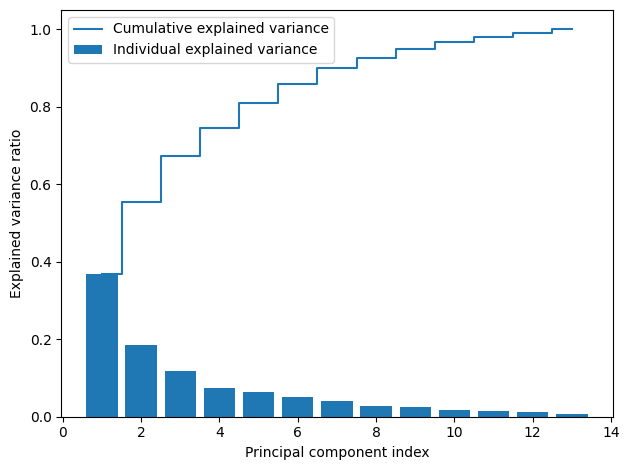

In [7]:
tot = sum(eigen_vals)
var_exp = [(i / tot) for i in sorted(eigen_vals, reverse=True)]
cum_var_exp = np.cumsum(var_exp)

import matplotlib.pyplot as plt
plt.bar(range(1, 14), var_exp, align='center',
        label='Individual explained variance')
plt.step(range(1, 14), cum_var_exp, where='mid',
         label='Cumulative explained variance')
plt.ylabel('Explained variance ratio')
plt.xlabel('Principal component index')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

The resulting plot indicates that the first principal component alone accounts for approximately 40
percent of the variance. Also, we can see that the first two principal components combined explain almost 60 percent of the variance in the dataset. So from this plot, say, if we want to capture 90% of the variance from the original data, we may choose $k = 8$.

##### Feature transformation. 

Now that we have successfully decomposed the covariance matrix into eigenpairs, let’s proceed with
the last three steps to transform the Wine dataset onto the new principal component axes. The remaining
steps we are going to tackle in this section are the following:

1. Select $k$ eigenvectors, which correspond to the $k$ largest eigenvalues, where $k$ is the dimensionality
of the new feature subspace ($k \le d$).
2. Construct a projection matrix, $W$, from the “top” $k$ eigenvectors. (**Note :** in above derivation, we used $u$ to represent PCA directions or axes)
3. Transform the $d$-dimensional input dataset, $X$, using the projection matrix, $W$, to obtain the
new $k$-dimensional feature subspace.
Or, in less technical terms, we will sort the eigenpairs by descending order of the eigenvalues, construct
a projection matrix from the selected eigenvectors, and use the projection matrix to transform
the data onto the lower-dimensional subspace.

We start by sorting the eigenpairs by decreasing order of the eigenvalues.

**Note :** The sorting process may not be required since the eigenvalues/eigenvectors are already sorted by numpy.linalg.eig. We just show how to do it in general case.


In [8]:
# Make a list of (eigenvalue, eigenvector) tuples
eigen_pairs = [(np.abs(eigen_vals[i]), eigen_vecs[:, i])
               for i in range(len(eigen_vals))]

# Sort the (eigenvalue, eigenvector) tuples from high to low
eigen_pairs.sort(key=lambda k: k[0], reverse=True)

Next, we collect the two eigenvectors that correspond to the two largest eigenvalues, to capture about
60 percent of the variance in this dataset. Note that two eigenvectors have been chosen for the purpose
of illustration, since we are going to plot the data via a two-dimensional scatterplot later in this subsection.
In practice, the number of principal components has to be determined by a tradeoff between
computational efficiency and the performance of the classifier.

In [9]:
w = np.hstack((eigen_pairs[0][1][:, np.newaxis],
               eigen_pairs[1][1][:, np.newaxis]))
print('Matrix W:\n', w)

Matrix W:
 [[-0.13724218  0.50303478]
 [ 0.24724326  0.16487119]
 [-0.02545159  0.24456476]
 [ 0.20694508 -0.11352904]
 [-0.15436582  0.28974518]
 [-0.39376952  0.05080104]
 [-0.41735106 -0.02287338]
 [ 0.30572896  0.09048885]
 [-0.30668347  0.00835233]
 [ 0.07554066  0.54977581]
 [-0.32613263 -0.20716433]
 [-0.36861022 -0.24902536]
 [-0.29669651  0.38022942]]


Using the projection matrix, we can now transform an example, $x$ (represented as a 13-dimensional
row vector), onto the PCA subspace (the principal components one and two) obtaining $x^′$, now a
two-dimensional example vector consisting of two new features.
$$
x^′ = xW \tag{7.9}
$$

In [10]:
X_train_std[0].dot(w)

array([2.38299011, 0.45458499])

Similarly, we can transform the entire 124×13-dimensional training dataset onto the two principal
components by calculating the matrix dot product
$$
X^′ = XW \tag{7.10}
$$

**Note :** One could verify that this operation yields the same result to (7.7) above (where we used $u$).

In [11]:
X_train_pca = X_train_std.dot(w)

Lastly, let’s visualize the transformed Wine training dataset, now stored as an 124×2-dimensional
matrix, in a two-dimensional scatterplot

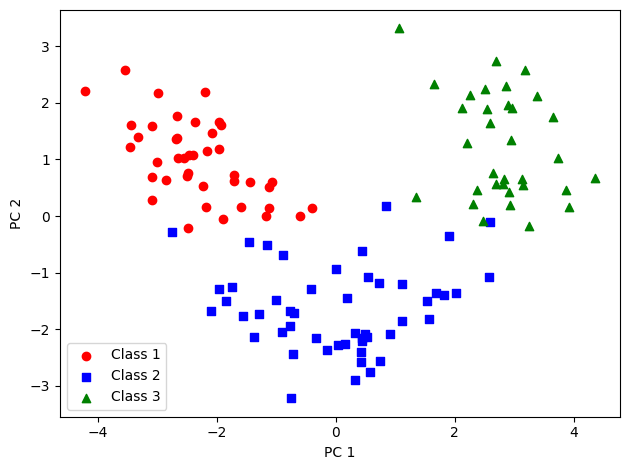

In [12]:
X_train_pca = X_train_std.dot(w)
colors = ['r', 'b', 'g']
markers = ['o', 's', '^']

for l, c, m in zip(np.unique(y_train), colors, markers):
    plt.scatter(X_train_pca[y_train == l, 0], 
                X_train_pca[y_train == l, 1], 
                c=c, label=f'Class {l}', marker=m)

plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()

As we can see from the scatter plot above, the data is more spread along the first principal component (PC1 axis) than
the second principal component (PC2 axis), which is consistent with the explained variance ratio plot
that we created in the previous subsection. However, we can tell that a linear classifier will likely be
able to separate the classes well.

Although we encoded the class label information for the purpose of illustration in the preceding
scatterplot, we have to keep in mind that PCA is an unsupervised technique that doesn’t use any class
label information

##### PCA in scikit-learn

First we replicate the result above using scikit-learn



In [13]:
from sklearn.decomposition import PCA

pca = PCA()
X_train_pca = pca.fit_transform(X_train_std)
pca.explained_variance_ratio_

array([0.36951469, 0.18434927, 0.11815159, 0.07334252, 0.06422108,
       0.05051724, 0.03954654, 0.02643918, 0.02389319, 0.01629614,
       0.01380021, 0.01172226, 0.00820609])

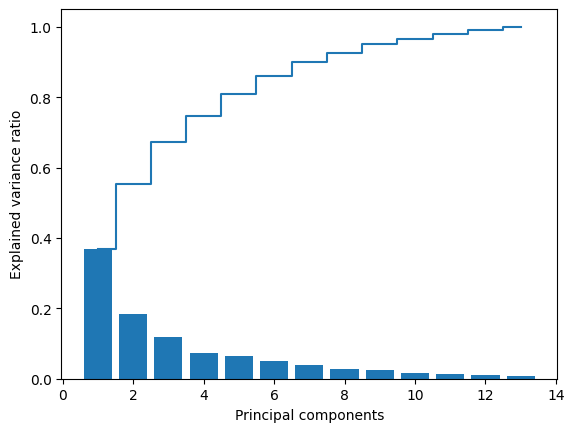

In [14]:
plt.bar(range(1, 14), pca.explained_variance_ratio_, align='center')
plt.step(range(1, 14), np.cumsum(pca.explained_variance_ratio_), where='mid')
plt.ylabel('Explained variance ratio')
plt.xlabel('Principal components')

plt.show()

In [15]:
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_std)
X_test_pca = pca.transform(X_test_std)

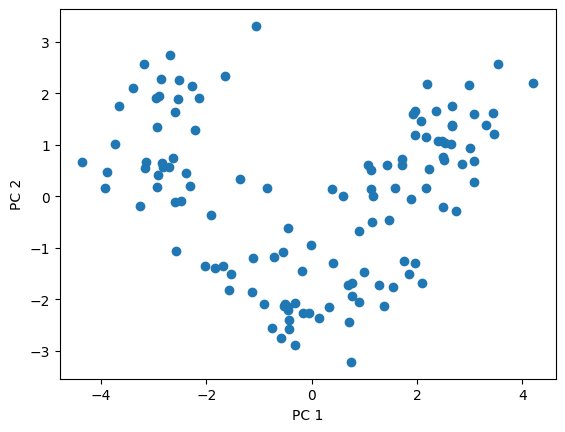

In [16]:
plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1])
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.show()

This plot is similar to the plot above, except that we assume now that we do not have class label information. (Remember that PCA is an unsupervised learning method.) 

The PCA class is another one of scikit-learn’s transformer classes, with which we first fit the model
using the training data before we transform both the training data and the test dataset using the
same model parameters. Now, let’s use the PCA class from scikit-learn on the Wine training dataset,
classify the transformed examples via logistic regression, and visualize the decision regions via the
plot_decision_regions function that we used in previous lectures.

In [17]:
from matplotlib.colors import ListedColormap

def plot_decision_regions(X, y, classifier, test_idx=None, resolution=0.02):

    # setup marker generator and color map
    markers = ('o', 's', '^', 'v', '<')
    colors = ('red', 'blue', 'lightgreen', 'gray', 'cyan')
    cmap = ListedColormap(colors[:len(np.unique(y))])

    # plot the decision surface
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, resolution),
                           np.arange(x2_min, x2_max, resolution))
    lab = classifier.predict(np.array([xx1.ravel(), xx2.ravel()]).T)
    lab = lab.reshape(xx1.shape)
    plt.contourf(xx1, xx2, lab, alpha=0.3, cmap=cmap)
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())

    # plot class examples
    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(x=X[y == cl, 0], 
                    y=X[y == cl, 1],
                    alpha=0.8, 
                    c=colors[idx],
                    marker=markers[idx], 
                    label=f'Class {cl}', 
                    edgecolor='black')

Training logistic regression classifier using the first 2 principal components.

In [46]:
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier 

pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_std)
X_test_pca = pca.transform(X_test_std)

# lr = LogisticRegression(multi_class='ovr', random_state=1, solver='lbfgs') # original code from book has some warning
lr = OneVsRestClassifier(LogisticRegression(random_state=1, solver='lbfgs')) # fix as recommended by scikit-learn
# lr = LogisticRegression(random_state=1, solver='lbfgs')
lr = lr.fit(X_train_pca, y_train)

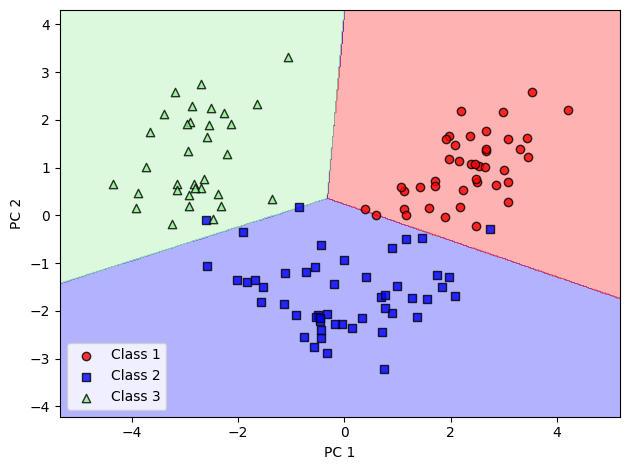

In [47]:
plot_decision_regions(X_train_pca, y_train, classifier=lr)
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()

We see that the decision regions for the training data reduced to two
principal component axes. When we compare the PCA projections via scikit-learn with our own PCA implementation, we might see that the resulting plots are mirror images of each other. Note that this is not due to an error in
either of those two implementations; the reason for this difference is that, depending on the eigensolver,
eigenvectors can have either negative or positive signs. 

Let's plot the decision regions of the logistic regression on the transformed test dataset to see if it can
separate the classes well.

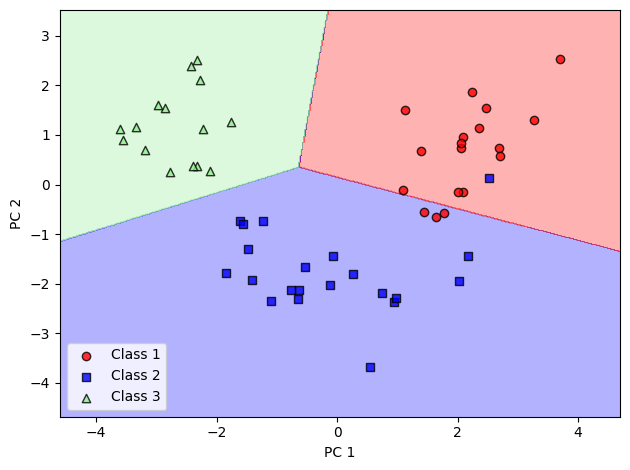

In [20]:
plot_decision_regions(X_test_pca, y_test, classifier=lr)
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()

We can see from the plot result that logistic regression performs quite well on this small two-dimensional feature subspace and only
misclassifies a few examples in the test dataset.

If we are interested in the explained variance ratios of the different principal components, we can
simply initialize the PCA class with the n_components parameter set to None, so all principal components
are kept and the explained variance ratio can then be accessed via the explained_variance_ratio_
attribute.

In [21]:
pca = PCA(n_components=None)
X_train_pca = pca.fit_transform(X_train_std)
pca.explained_variance_ratio_

array([0.36951469, 0.18434927, 0.11815159, 0.07334252, 0.06422108,
       0.05051724, 0.03954654, 0.02643918, 0.02389319, 0.01629614,
       0.01380021, 0.01172226, 0.00820609])

Note that we set n_components=None when we initialized the PCA class so that it will return all principal
components in a sorted order, instead of performing a dimensionality reduction.

##### Assessing feature contributions

In this section, we will take a brief look at how we can assess the contributions of the original features
to the principal components. As we learned, via PCA, we create principal components that represent
linear combinations of the features. Sometimes, we are interested to know about how much each original
feature contributes to a given principal component. These contributions are often called loadings.
The factor loadings can be computed by scaling the eigenvectors by the square root of the eigenvalues.
The resulting values can then be interpreted as the correlation between the original features and
the principal component. To illustrate this, let us plot the loadings for the first principal component.
First, we compute the 13×13-dimensional loadings matrix by multiplying the eigenvectors by the
square root of the eigenvalues.

In [22]:
loadings = eigen_vecs * np.sqrt(eigen_vals)

Then, we plot the loadings for the first principal component, loadings[:, 0], which is the first column in this matrix.

In [23]:
loadings[:, 0]

array([-0.3020184 ,  0.54408942, -0.05600938,  0.45540829, -0.33970111,
       -0.8665386 , -0.9184327 ,  0.67279444, -0.67489496,  0.16623657,
       -0.71769524, -0.81117245, -0.65291742])

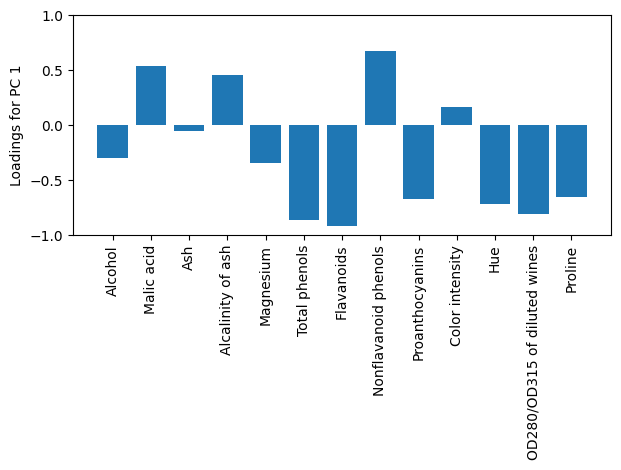

In [24]:
fig, ax = plt.subplots()

ax.bar(range(13), loadings[:, 0], align='center')
ax.set_ylabel('Loadings for PC 1')
ax.set_xticks(range(13))
ax.set_xticklabels(df_wine.columns[1:], rotation=90)

plt.ylim([-1, 1])
plt.tight_layout()
plt.show()

In the figure above, we can see that, for example, Alcohol has a negative correlation with the first principal
component (approximately –0.3), whereas Malic acid has a positive correlation (approximately 0.54).
Note that a value of 1 describes a perfect positive correlation whereas a value of –1 corresponds to a
perfect negative correlation.

In the preceding code example, we compute the factor loadings for our own PCA implementation.
We can obtain the loadings from a fitted scikit-learn PCA object in a similar manner, where pca.
components_ represents the eigenvectors and pca.explained_variance_ represents the eigenvalues.

In [25]:
sklearn_loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

To compare the scikit-learn PCA loadings with those we created previously, let us create a similar bar
plot.

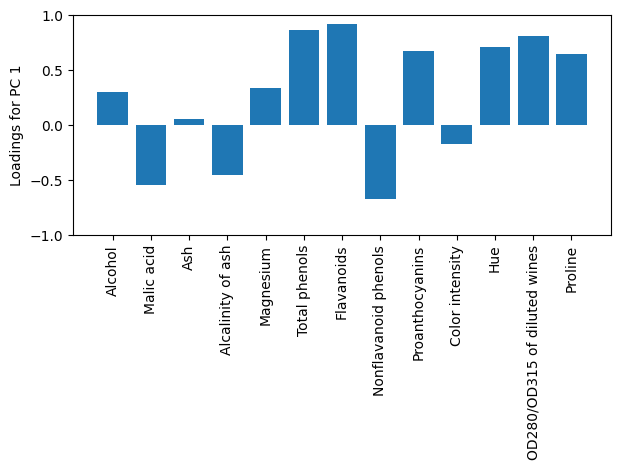

In [26]:
fig, ax = plt.subplots()

ax.bar(range(13), sklearn_loadings[:, 0], align='center')
ax.set_ylabel('Loadings for PC 1')
ax.set_xticks(range(13))
ax.set_xticklabels(df_wine.columns[1:], rotation=90)

plt.ylim([-1, 1])
plt.tight_layout()
plt.show()

### 7.2 Linear discriminant analysis

Linear Discriminant Analysis (LDA) can be used as a technique for feature extraction to increase computational efficiency and reduce the degree of overfitting due to the curse of dimensionality in non-regularized models. The general concept behind LDA is very similar to PCA, but whereas PCA attempts to find the orthogonal component axes of maximum variance in a dataset, the goal in LDA is to find the feature subspace that optimizes class separability. 

<hr>

##### Aside

[This video](https://www.youtube.com/watch?v=C0u_v7vEDBY) explains LDA in great details, especially the underlying mathematics. However, the instructor derived LDA via a different route compared to [1]. He started with LDA as an estmation for $P(X|y)$ in contrast to $P(y|X)$ as in logistic regression. The general setup led to Quadratic Discriminant Analysis (QDA), but after more assumption on equality covariance matrices then it reduced to LDA. The decision boundary looks like the one in Figure  7.7.

<img src="https://raw.githubusercontent.com/dewdotninja/mlpi/refs/heads/main/figures/lda01.png" width=800 />

 Figure 7.7  decision boundary of LDA 

To conform to the assumption, we need to form a mutual covariance matrix from data, called a pooled covariance, as shown in Figure 7.8

<img src="https://raw.githubusercontent.com/dewdotninja/mlpi/refs/heads/main/figures/lda02.png" width=800 />

 Figure 7.8  pooled covariance in LDA 

Watch the video to see derivation details. Until near the end, he mentioned [Fisher's discriminant analysis](https://youtu.be/C0u_v7vEDBY?si=INYm8zDg2mDzzMoT&t=2649) as a different route. 

In this notebook, we choose to follow [1] that follows Fisher LDA approach, with emphasis on running the code.

<hr>

Both PCA and LDA are linear transformation techniques that can be used to reduce the number of dimensions
in a dataset; the former is an unsupervised algorithm, whereas the latter is supervised. LDA is quite similar to PCA in the sense that we are decomposing matrices into eigenvalues
and eigenvectors, which will form the new lower-dimensional feature space. However, as
mentioned before, LDA takes class label information into account. The main steps required to perform LDA are as follows:

1. Standardize the $d$-dimensional dataset ($d$ is the number of features).
2. For each class, compute the $d$-dimensional mean vector.
3. Construct the between-class scatter matrix, $S_B,$ and the within-class scatter matrix, $S_W$.
4. Compute the eigenvectors and corresponding eigenvalues of the matrix, $X_W^{-1}S_B$ .
5. Sort the eigenvalues by decreasing order to rank the corresponding eigenvectors.
6. Choose the $k$ eigenvectors that correspond to the k largest eigenvalues to construct a $d \times k$-dimensional
transformation matrix, $W$; the eigenvectors are the columns of this matrix.
7. Project the examples onto the new feature subspace using the transformation matrix, $W$.


##### Computing the scatter matrices

Since we already standardized the features of the Wine dataset in the PCA section, we can skip step 1 and preceed with the calculation of the mean vectors, which we will use to construct the within-class scatter matrix and between-class scatter matrix, respectively. 

Each mean vector $m_i$ stores the mean feature value $\mu_m$ with respect to the examples of class $i$.
$$
m_i = \frac{1}{n_i}\sum_{x \in D_i}x_m \tag{7.11}
$$
This results in three mean vectors
$$
m_i = \left[\begin{array}{c}
\mu_{i,alcohol} \\
\mu_{i,malic acid} \\
\vdots  \\
\mu_{i, proline}
\end{array}\right] \tag{7.12}
$$
These mean vectors can be computed by the following code, where we compute one mean vector for
each of the three labels.

In [27]:
np.set_printoptions(precision=4)
mean_vecs = []
for label in range(1, 4):
    mean_vecs.append(np.mean(X_train_std[y_train == label], axis=0))
    print(f'MV {label}: {mean_vecs[label - 1]}\n')

MV 1: [ 0.9066 -0.3497  0.3201 -0.7189  0.5056  0.8807  0.9589 -0.5516  0.5416
  0.2338  0.5897  0.6563  1.2075]

MV 2: [-0.8749 -0.2848 -0.3735  0.3157 -0.3848 -0.0433  0.0635 -0.0946  0.0703
 -0.8286  0.3144  0.3608 -0.7253]

MV 3: [ 0.1992  0.866   0.1682  0.4148 -0.0451 -1.0286 -1.2876  0.8287 -0.7795
  0.9649 -1.209  -1.3622 -0.4013]



Using the mean vectors, we can now compute the within-class scatter matrix, $S_W$
$$
S_W = \sum_{i=1}^cS_i \tag{7.13}
$$
This is calculated by summing up the individual scatter matrices, $S_i$, of each individual class $i$.
$$
S_i = \sum_{x \in D_i}(x-m_i)(x-m_i)^T \tag{7.14}
$$

In [28]:
d = 13 # number of features
S_W = np.zeros((d, d))
for label, mv in zip(range(1, 4), mean_vecs):
    class_scatter = np.zeros((d, d))  # scatter matrix for each class
    for row in X_train_std[y_train == label]:
        row, mv = row.reshape(d, 1), mv.reshape(d, 1)  # make column vectors
        class_scatter += (row - mv).dot((row - mv).T)
    S_W += class_scatter                          # sum class scatter matrices

print('Within-class scatter matrix: '
      f'{S_W.shape[0]}x{S_W.shape[1]}')

Within-class scatter matrix: 13x13


The assumption that we are making when we are computing the scatter matrices is that the class labels 
in the training dataset are uniformly distributed. However, if we print the number of class labels, we 
see that this assumption is violated.

In [29]:
print('Class label distribution:',  
      np.bincount(y_train)[1:])

Class label distribution: [41 50 33]


Thus, we want to scale the individual scatter matrices, $S_i$, before we sum them up as the scatter matrix, 
$S_W$. When we divide the scatter matrices by the number of class-examples, $n_i$, we can see that computing the scatter matrix is in fact the same as computing the covariance matrix, $\Sigma_i$—the covariance 
matrix is a normalized version of the scatter matrix
$$
\Sigma_i = \frac{1}{n_i}S_i = \frac{1}{n_i}\sum_{x \in D_i}(x-m_i)(x-m_i)^T \tag{7.15}
$$
The code for computing the scaled within-class scatter matrix is as follows.

In [30]:
d = 13  # number of features
S_W = np.zeros((d, d))
for label, mv in zip(range(1, 4), mean_vecs):
    class_scatter = np.cov(X_train_std[y_train == label].T)
    S_W += class_scatter
    
print('Scaled within-class scatter matrix: '
      f'{S_W.shape[0]}x{S_W.shape[1]}')

Scaled within-class scatter matrix: 13x13


After we compute the scaled within-class scatter matrix (or covariance matrix), we can move on to 
the next step and compute the between-class scatter matrix $S_B$
$$
S_B = \sum_{i=1}^cn_i(m_i-m)(m_i - m)^T \tag{7.16}
$$
Here, $m$ is the overall mean that is computed, including examples from all $c$ classes.

In [31]:
mean_overall = np.mean(X_train_std, axis=0)
mean_overall = mean_overall.reshape(d, 1)  # make column vector

d = 13  # number of features
S_B = np.zeros((d, d))

for i, mean_vec in enumerate(mean_vecs):
    n = X_train_std[y_train == i + 1, :].shape[0]
    mean_vec = mean_vec.reshape(d, 1)  # make column vector
    S_B += n * (mean_vec - mean_overall).dot((mean_vec - mean_overall).T)

print('Between-class scatter matrix: '
      f'{S_B.shape[0]}x{S_B.shape[1]}')

Between-class scatter matrix: 13x13


#### Selecting linear discriminants for the new feature subspace

The remaining steps of the LDA are similar to the steps of the PCA. However, instead of performing
the eigendecomposition on the covariance matrix, we solve the generalized eigenvalue problem of
the matrix $S_W^{-1}S_B$.

In [ ]:
eigen_vals, eigen_vecs = np.linalg.eig(np.linalg.inv(S_W).dot(S_B))
# eigen_vals, eigen_vecs = np.linalg.eigh(np.linalg.inv(S_W).dot(S_B)) # always return real eigenvalues

After we compute the eigenpairs, we can sort the eigenvalues in descending order.

In [33]:
# Make a list of (eigenvalue, eigenvector) tuples
eigen_pairs = [(np.abs(eigen_vals[i]), eigen_vecs[:, i])
               for i in range(len(eigen_vals))]

# Sort the (eigenvalue, eigenvector) tuples from high to low
eigen_pairs = sorted(eigen_pairs, key=lambda k: k[0], reverse=True)

# Visually confirm that the list is correctly sorted by decreasing eigenvalues

print('Eigenvalues in descending order:\n')
for eigen_val in eigen_pairs:
    print(eigen_val[0])

Eigenvalues in descending order:

349.61780890599397
172.7615221897939
3.206766566344046e-14
3.206766566344046e-14
2.0503142892744868e-14
1.5034839849248245e-14
1.099380811667537e-14
1.099380811667537e-14
5.475548617272529e-15
5.407107312284894e-15
5.407107312284894e-15
1.6198550109097073e-15
0.0


In LDA, the number of linear discriminants is at most $c-1$, where $c$ is the number of class labels, since
the in-between scatter matrix, $S_B$, is the sum of $c$ matrices with rank one or less. We can indeed see
that we only have two nonzero eigenvalues (the eigenvalues 3-13 are not exactly zero, but this is due
to the floating-point arithmetic in NumPy.)

<hr>

**Collinearity** 

Note that in the rare case of perfect collinearity (all aligned example points fall on a
straight line), the covariance matrix would have rank one, which would result in only one
eigenvector with a nonzero eigenvalue.

<hr>

To measure how much of the class-discriminatory information is captured by the linear discriminants
(eigenvectors), let’s plot the linear discriminants by decreasing eigenvalues, similar to the explained
variance plot that we created in the PCA section. For simplicity, we will call the content of class-discriminatory
information discriminability. 


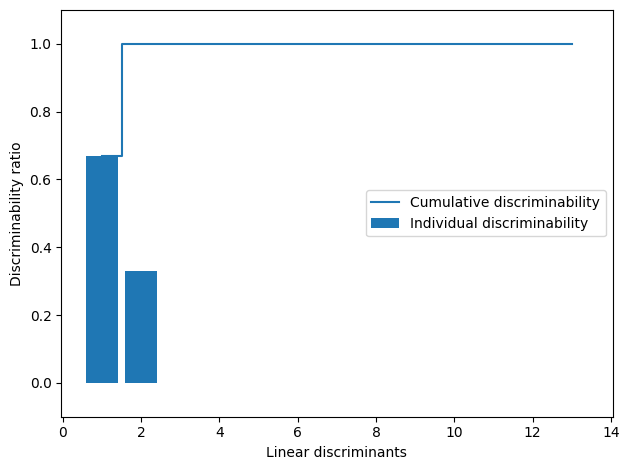

In [34]:
tot = sum(eigen_vals.real)
discr = [(i / tot) for i in sorted(eigen_vals.real, reverse=True)]
cum_discr = np.cumsum(discr)

plt.bar(range(1, 14), discr, align='center',
        label='Individual discriminability')
plt.step(range(1, 14), cum_discr, where='mid',
         label='Cumulative discriminability')
plt.ylabel('Discriminability ratio')
plt.xlabel('Linear discriminants')
plt.ylim([-0.1, 1.1])
plt.legend(loc='best')
plt.tight_layout()
plt.show()

As we can see in the plot above, the first two linear discriminants alone capture 100 percent of the useful
information in the Wine training dataset.

Let’s now stack the two most discriminative eigenvector columns to create the transformation matrix,
$W$.

In [35]:
w = np.hstack((eigen_pairs[0][1][:, np.newaxis].real,
              eigen_pairs[1][1][:, np.newaxis].real))
print('Matrix W:\n', w)

Matrix W:
 [[-0.1481 -0.4092]
 [ 0.0908 -0.1577]
 [-0.0168 -0.3537]
 [ 0.1484  0.3223]
 [-0.0163 -0.0817]
 [ 0.1913  0.0842]
 [-0.7338  0.2823]
 [-0.075  -0.0102]
 [ 0.0018  0.0907]
 [ 0.294  -0.2152]
 [-0.0328  0.2747]
 [-0.3547 -0.0124]
 [-0.3915 -0.5958]]


#### Projecting examples onto the new feature space

Using the transformation matrix $W$ that we created in the previous subsection, we can now transform
the training dataset by multiplying the matrices $X^′ = XW$.

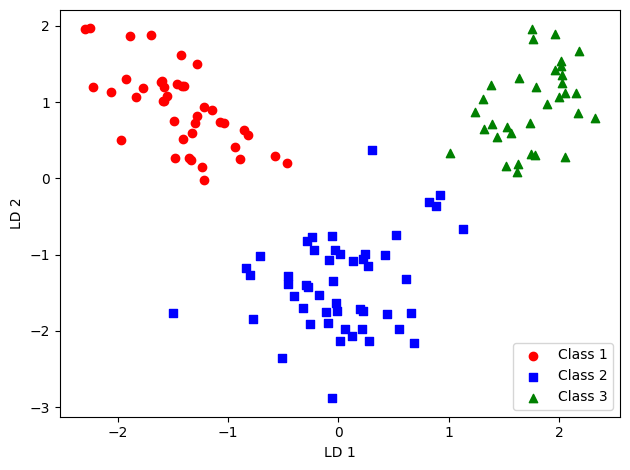

In [36]:
X_train_lda = X_train_std.dot(w)
colors = ['r', 'b', 'g']
markers = ['o', 's', '^']

for l, c, m in zip(np.unique(y_train), colors, markers):
    plt.scatter(X_train_lda[y_train == l, 0],
                X_train_lda[y_train == l, 1] * (-1),
                c=c, label=f'Class {l}', marker=m)

plt.xlabel('LD 1')
plt.ylabel('LD 2')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

As we can see in the figure above, the three Wine classes are now perfectly linearly separable in the new
feature subspace.

#### LDA vid scikit-learn

That step-by-step implementation was a good exercise to understand the inner workings of LDA and
understand the differences between LDA and PCA. Now, let’s look at the LDA class implemented in
scikit-learn.

In [37]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

lda = LDA(n_components=2)
X_train_lda = lda.fit_transform(X_train_std, y_train)

Next, let’s see how the logistic regression classifier handles the lower-dimensional training dataset
after the LDA transformation.

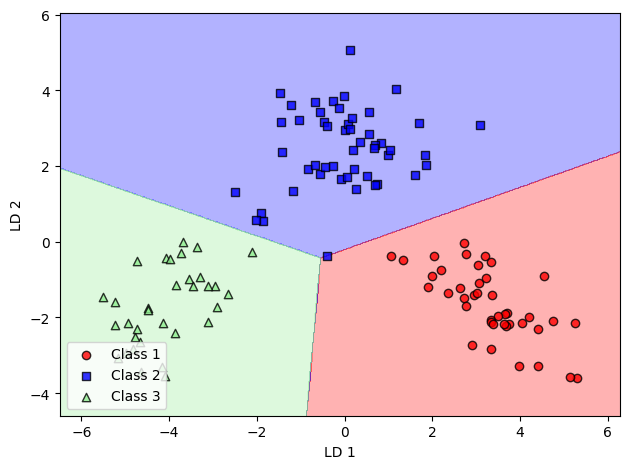

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier

# lr = LogisticRegression(multi_class='ovr', random_state=1, solver='lbfgs') # code from book has some warning
lr = OneVsRestClassifier(LogisticRegression(random_state=1, solver='lbfgs')) # modified a little from book to get rid of warning
# lr = LogisticRegression(random_state=1, solver='lbfgs') # this gives slightly different result
lr = lr.fit(X_train_lda, y_train)

plot_decision_regions(X_train_lda, y_train, classifier=lr)
plt.xlabel('LD 1')
plt.ylabel('LD 2')
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()

Looking at Figure above, we can see that the logistic regression model misclassifies one of the examples
from class 2.By lowering the regularization strength, we could probably shift the decision boundaries so that the
logistic regression model classifies all examples in the training dataset correctly. However, and more
importantly, let’s take a look at the results on the test dataset.

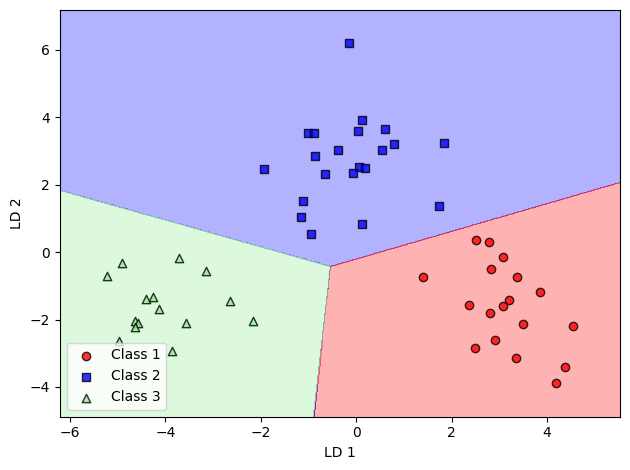

In [44]:
X_test_lda = lda.transform(X_test_std)

plot_decision_regions(X_test_lda, y_test, classifier=lr)
plt.xlabel('LD 1')
plt.ylabel('LD 2')
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()

As we can see from the result, the logistic regression classifier is able to get a perfect accuracy score for
classifying the examples in the test dataset by only using a two-dimensional feature subspace, instead
of the original 13 Wine features.

### Related Videos

#### Lectures from top universities
<ul>
<li />CS229-2018 : <a href="https://youtu.be/I_c6w1SJSJs?si=xvzgVdbwnlOjYGbo">Principal Component Analysis</a> 
<li />CS229-2022 : <a href="https://youtu.be/o2KzJdbOwMc?si=yR257TC16r97v538">Lecture 14</a> <a href="https://youtu.be/FVLZG_oHUIw?si=Y7wIzoZQ7EXbgDc7">Lecture 15</a>
<li />MIT 9.40-2018 : <a href="https://youtu.be/N-49t1j-XWY?si=JQW7-jfDydOB8n6I">17 : Principal Components Analysis</a>
<li />University of Tübingen Machine Learning I : <a href="https://youtu.be/xBf_LZ5ZgY4?si=MkPrxo8HGsmivLDT">10 - Principal component analysis</a>
<li />University of Tübingen Machine Learning I : <a href="https://youtu.be/C0u_v7vEDBY?si=B9gb0JePe5C_KYGX">06 - Linear discriminant analysis</a>
</ul>

#### Simpler to watch
<ul>
<li />TileStats : <a href="https://youtu.be/dz8imS1vwIM?si=Yz4w41R7n69mj9aX">PCA : the basics - explained super simple</a>
<li />TileStats : <a href="https://youtu.be/S51bTyIwxFs?si=jUqoPy6cVhNiyzRD">PCA : the math - step-by-step with a simple example</a>
<li />TileStats : <a href="https://youtu.be/julEqA2ozcA?si=E3LeTqOSHrkILzlB">Linear discriminant analysis (LDA) - simply explained </a>
</ul>



### References

1. S. Raschka, Y. Liu and V. Mirjalili. [Machine Learning with PyTorch 
and Scikit-Learn.](https://sebastianraschka.com/blog/2022/ml-pytorch-book.html) Packt Publishing. 2022.  

2. A. Ng. [CS229 Lecture Notes.](https://cs229.stanford.edu/main_notes.pdf) Stanford University. 2023.




<div align="center">
<img src="https://raw.githubusercontent.com/dewdotninja/sharing-github/refs/heads/master/dewninja_logo50.jpg" alt="dewninja"/>
</div>
<div align="center">dew.ninja 2025</div>